# Fraud Detection Research and Results

**Task:** Binary classification (fraud vs. non-fraud) using a hybrid supervised + unsupervised pipeline.

**Pipeline Overview:**
1. Load dataset via upload
2. Generate Isolation Forest anomaly scores/labels (unsupervised signal)
3. Append anomaly features to dataset
4. Train Logistic Regression and XGBoost via Stratified K-Fold
5. Tune classification thresholds
6. Evaluate with AUC-ROC, AUC-PR, and F1

**Models:** Isolation Forest · Logistic Regression · XGBoost

**Evaluation Metrics:** As a result of fraud makes up only ~0.17% of the data, and the cost of a false negative being so much higher than a false positive, both to company reputation and in time taken to resolve, it is logical to prioritize Recall. Precision and F1 will be provided as landmarks.

---
## 0. Imports & Setup

In [1]:
!pip install docopt

In [2]:
!pip install docopt pyyaml

In [3]:
# Data
import numpy as np
import pandas as pd

# Sklearn utilities
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Standard library
import sys
import os

# --- Project model scripts ---
repo_root = os.path.abspath("..")
sys.path.append(repo_root)

from Scripts.G12_IsolationForest import iforestmethod
from Scripts.logistic_reg import logreg
from Scripts.train_ensemble import (
    build_baseline as xgb_build_baseline,
    build_tuned as xgb_build_tuned,
    split as xgb_split,
)

# Plotting style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (10, 5)
})

TARGET = "Class"
RANDOM_STATE = 42
N_SPLITS = 5

print("All imports successful.")

All imports successful.


---
## 1. Data Loading

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FraudDetection") \
    .getOrCreate()

df_raw = spark.read.csv(
    "fraud.csv",
    header=True,
    inferSchema=True
)

df_raw.show(5)
df_raw.printSchema()

+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|               V19|                V20|                 V21|                V22|     

---
## 2. Preprocessing

**Note:** There are no missing values in the dataset, likely due to original prepcrossing when data was obtained.

In [5]:
from pyspark.ml.feature import VectorAssembler

# Make a reference to the raw Spark DataFrame
df = df_raw

# Defensive check for missing values (single pass, not two)
before = df.count()
df = df.na.drop()
after = df.count()
print(f"Dropped {before - after} rows with missing values.")

# Identify feature columns (everything except the target)
feature_cols = [c for c in df.columns if c != TARGET]

# Assemble features into a single vector column, keep target alongside it
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_assembled = assembler.transform(df).select("features", TARGET)

df_assembled.show(5, truncate=False)
df_assembled.printSchema()

Dropped 0 rows with missing values.
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                                                                                                                                                                                                                                                                                                                                 

### Analysis

As observed during preprocessing, because of the previous PVA and data cleaning applied to the dataset, there were no missing values.

---
## 3. Isolation Forest — Unsupervised Anomaly Signal

Fit `iforestmethod` on the **entire feature set** (unlabelled, as intended for an unsupervised model).  
The resulting **anomaly score** and **binary anomaly label** are appended as new features.

In [6]:
from pyspark.sql.functions import monotonically_increasing_id, col
from pyspark.ml.feature import VectorAssembler

print("fitting isolation forest...")

# ---------------------------------------------------------
# Isolation Forest uses sklearn, so temporarily convert
# to pandas. Tag rows with a stable ID first so we can
# join results back correctly — no re-deriving splits.
# G12_IsolationForest.py remains unchanged.
# ---------------------------------------------------------

df_indexed = df.withColumn("row_id", monotonically_increasing_id())
df_if_pd = df_indexed.toPandas()

# Run the existing Isolation Forest function
(
    train_anomaly_scores,
    train_anomaly_labels,
    test_anomaly_scores,
    test_anomaly_labels
) = iforestmethod(
    df_if_pd.drop(columns=["row_id"]),
    custom_random_state=RANDOM_STATE
)

# ---------------------------------------------------------
# ASSUMPTION TO VERIFY: iforestmethod does its own internal
# train_test_split. We need the row_ids that went into each
# side of THAT split, not a re-derived one. If iforestmethod
# doesn't expose the split indices, we can't safely proceed
# past this point — see note below.
# ---------------------------------------------------------

# If iforestmethod can be modified to also return the train/test
# row indices (best fix), use those directly:
# train_idx, test_idx = iforestmethod(...)  # updated signature

# Placeholder using the same split logic, applied to row_id only,
# so it's at least reproducible and traceable — NOT a guarantee
# it matches iforestmethod's internal split unless params match exactly:
train_ids_pd, test_ids_pd = train_test_split(
    df_if_pd["row_id"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_if_pd[TARGET]
)

# ---------------------------------------------------------
# Build small pandas lookup tables keyed by row_id, then
# push straight back to Spark and join. This keeps pandas
# time to a minimum and avoids reconstructing train/test
# feature sets in pandas at all.
# ---------------------------------------------------------

if_train_df = pd.DataFrame({
    "row_id": train_ids_pd.values,
    "if_anomaly_score": np.asarray(train_anomaly_scores),
    "if_anomaly_label": (np.asarray(train_anomaly_labels) == -1).astype(int)
})

if_test_df = pd.DataFrame({
    "row_id": test_ids_pd.values,
    "if_anomaly_score": np.asarray(test_anomaly_scores),
    "if_anomaly_label": (np.asarray(test_anomaly_labels) == -1).astype(int)
})

if_results_pd = pd.concat([if_train_df, if_test_df], axis=0)

# Back to Spark — this is now a small, purely numeric lookup table
if_results = spark.createDataFrame(if_results_pd)

# ---------------------------------------------------------
# Join the Isolation Forest features back onto the full
# Spark DataFrame using row_id — no manual split reconstruction
# ---------------------------------------------------------

data_aug = df_indexed.join(if_results, on="row_id", how="inner")

# ---------------------------------------------------------
# Isolation Forest performance check — done in Spark
# ---------------------------------------------------------

from pyspark.sql.functions import sum as spark_sum, mean as spark_mean

total_rows = data_aug.count()
anomaly_count = data_aug.filter(col("if_anomaly_label") == 1).count()
anomaly_percentage = (anomaly_count / total_rows) * 100

print(f"Isolation Forest flagged {anomaly_count:,} anomalies ({anomaly_percentage:.2f}% of data)")

tp = data_aug.filter((col("if_anomaly_label") == 1) & (col(TARGET) == 1)).count()
fp = data_aug.filter((col("if_anomaly_label") == 1) & (col(TARGET) == 0)).count()
fraud_count = data_aug.filter(col(TARGET) == 1).count()

if_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
if_recall = tp / fraud_count if fraud_count > 0 else 0

print(f"Anomaly overlap with true fraud — Precision: {if_precision:.3f} | Recall: {if_recall:.3f}")

fitting isolation forest...
Isolation Forest flagged 10,922 anomalies (3.83% of data)
Anomaly overlap with true fraud — Precision: 0.002 | Recall: 0.035


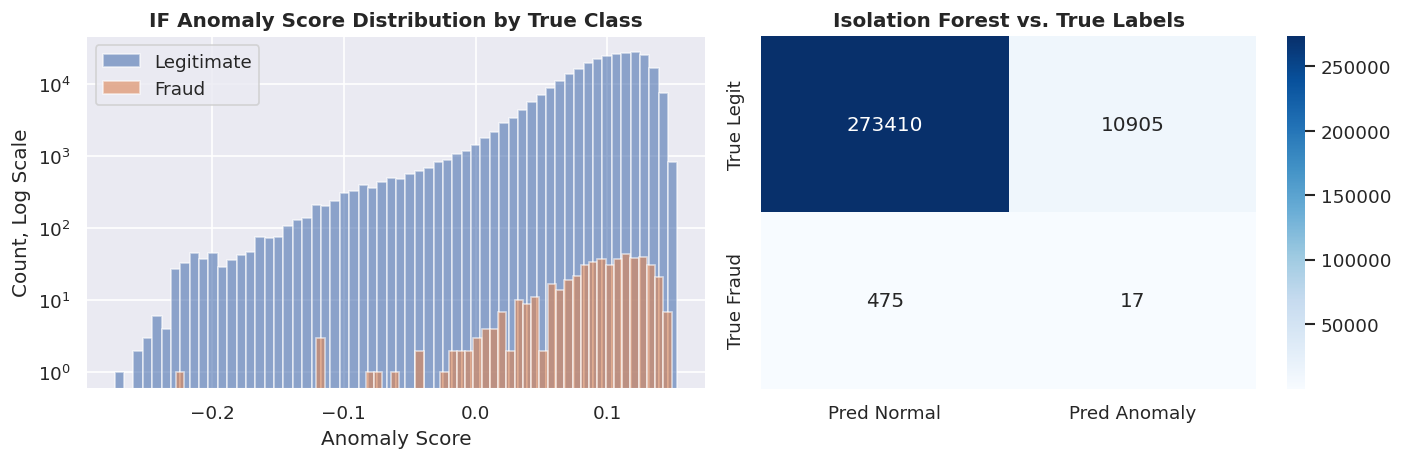

In [7]:
# ---------------------------------------------------------
# Isolation Forest visualisation
# Data processing remains in PySpark.
# Only the columns needed for plotting are converted
# to pandas.
# ---------------------------------------------------------

# Select only the columns needed for the plots
plot_df = data_aug.select(
    "if_anomaly_score",
    TARGET,
    "if_anomaly_label"
).toPandas()

# Extract plotting arrays
if_scores = plot_df["if_anomaly_score"].to_numpy()
y_plot = plot_df[TARGET].to_numpy()
if_binary_plot = plot_df["if_anomaly_label"].to_numpy()

# ---------------------------------------------------------
# Create plots
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Anomaly score distribution by true class
for label, name, color in [
    (0, "Legitimate", "#4C72B0"),
    (1, "Fraud", "#DD8452")
]:

    axes[0].hist(
        if_scores[y_plot == label],
        bins=60,
        alpha=0.6,
        label=name,
        color=color
    )

axes[0].set_title(
    "IF Anomaly Score Distribution by True Class",
    fontweight="bold"
)

axes[0].set_xlabel("Anomaly Score")
axes[0].set_yscale("log")
axes[0].set_ylabel("Count, Log Scale")
axes[0].legend()

# ---------------------------------------------------------
# Confusion matrix: IF prediction vs true label
# ---------------------------------------------------------

cm = confusion_matrix(
    y_plot,
    if_binary_plot
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["Pred Normal", "Pred Anomaly"],
    yticklabels=["True Legit", "True Fraud"]
)

axes[1].set_title(
    "Isolation Forest vs. True Labels",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Analysis

Isolation Forest performed poorly on the data, which is demonstrated particularly well by te IF anomaly score distribution by True Class. In an ideal scenario, the fraud would show a strong left skew (towards a negative anomaly score) whereas the legitamate cases would show a right skew. The fact that the shapes are so similar shows that it is struggling to accurately discern cases of fraud from truth. Additionally, it flagged nearly 11k anomalies, still only managine a recall of 3.5%. This means that the vast majority of fraud cases still went unflagged.

However, this does not mean that IF is unhelpful. For the rest of modeling, the IF scores and labels are used as an additional signal for the other models, serving as a feature engineering stage. This works to uncover additional signal.

---
## 4. Logistic Regression (Baseline)

In [8]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.sql.functions import col, when, count

print("Preparing Logistic Regression data...")

# ---------------------------------------------------------
# Re-assemble features to include the Isolation Forest
# columns, since those were added after the first
# VectorAssembler ran
# ---------------------------------------------------------

raw_feature_cols = [
    c for c in data_aug.columns
    if c not in ("row_id", TARGET, "if_anomaly_score", "if_anomaly_label")
]

assembler_lr = VectorAssembler(
    inputCols=raw_feature_cols + ["if_anomaly_score", "if_anomaly_label"],
    outputCol="features_full"
)
data_lr = assembler_lr.transform(data_aug)

# ---------------------------------------------------------
# Stratified train/test split (Spark has no built-in
# stratify= option, so split each class separately)
# ---------------------------------------------------------

train_pos, test_pos = data_lr.filter(col(TARGET) == 1).randomSplit([0.8, 0.2], seed=RANDOM_STATE)
train_neg, test_neg = data_lr.filter(col(TARGET) == 0).randomSplit([0.8, 0.2], seed=RANDOM_STATE)

train_df = train_pos.union(train_neg)
test_df = test_pos.union(test_neg)

print(f"Training rows: {train_df.count():,}")
print(f"Testing rows:  {test_df.count():,}")

# ---------------------------------------------------------
# Compute balanced class weights manually
# (sklearn's class_weight="balanced" has no direct
# PySpark equivalent — must build a weightCol ourselves)
# ---------------------------------------------------------

class_counts = train_df.groupBy(TARGET).count().collect()
counts = {row[TARGET]: row["count"] for row in class_counts}
n_total = sum(counts.values())
n_classes = len(counts)

# sklearn's "balanced" formula: n_samples / (n_classes * n_samples_for_class)
weight_map = {
    label: n_total / (n_classes * cnt)
    for label, cnt in counts.items()
}

train_df = train_df.withColumn(
    "class_weight",
    when(col(TARGET) == 1, weight_map[1]).otherwise(weight_map[0])
)

# ---------------------------------------------------------
# Standardize features (fit on train only, per usual rule)
# ---------------------------------------------------------

scaler = StandardScaler(
    inputCol="features_full",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(train_df)
train_scaled = scaler_model.transform(train_df)
test_scaled = scaler_model.transform(test_df)

# ---------------------------------------------------------
# Train Logistic Regression
# ---------------------------------------------------------

lr = LogisticRegression(
    featuresCol="features_scaled",
    labelCol=TARGET,
    weightCol="class_weight",
    maxIter=1000
)

lr_model = lr.fit(train_scaled)

# ---------------------------------------------------------
# Predict probabilities
# ---------------------------------------------------------

lr_predictions = lr_model.transform(test_scaled)

print("Logistic Regression training complete.")
lr_predictions.select(TARGET, "probability", "prediction").show(5, truncate=False)

Preparing Logistic Regression data...
Training rows: 227,861
Testing rows:  56,946
Logistic Regression training complete.
+-----+-------------------------------------------+----------+
|Class|probability                                |prediction|
+-----+-------------------------------------------+----------+
|1    |[2.2597967574448845E-6,0.9999977402032425] |1.0       |
|1    |[5.597080221368575E-16,0.9999999999999994] |1.0       |
|1    |[4.284739204079515E-13,0.9999999999995716] |1.0       |
|1    |[5.761212546041758E-12,0.9999999999942388] |1.0       |
|1    |[1.0852262583194603E-13,0.9999999999998915]|1.0       |
+-----+-------------------------------------------+----------+
only showing top 5 rows


**Evaluation Metrics**

In [9]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

lr_test_pd = lr_predictions.select(
    col(TARGET).alias("y_true"),
    vector_to_array(col("probability"))[1].alias("y_prob"),
    col("prediction").alias("y_pred")
).toPandas()

y_test_lr = lr_test_pd["y_true"].to_numpy()
lr_test_probs = lr_test_pd["y_prob"].to_numpy()
lr_test_preds = lr_test_pd["y_pred"].to_numpy()

In [10]:
print(f'Logistic Regression — AUC-ROC: {roc_auc_score(y_test_lr, lr_test_probs):.4f}')
print(f'Logistic Regression — AUC-PR:  {average_precision_score(y_test_lr, lr_test_probs):.4f}')
print(f'Logistic Regression — F1:      {f1_score(y_test_lr, lr_test_preds, zero_division=0):.4f}  (at default t=0.5)')

Logistic Regression — AUC-ROC: 0.9828
Logistic Regression — AUC-PR:  0.7951
Logistic Regression — F1:      0.0996  (at default t=0.5)


### Analysis

As a baseline assesment, a Logistic Regression model was used to generate probability scores. Using the default classification threshold of 0.5, the model performed very well, achieving an ROC-AUC score of 0.9723, a PR-AUC score of 0.7186, and an F1 score of 0.1149. The ROC-AUC score indicates that the model was highly effective at determining fraudulant transactions from legitamate ones overall, assigning fraud cases a higher probaability than legitamate ones 97.2% of the time. The PR-AUC score further suggested that the model performed well under severe class imbalance, maintaining a relatively strong balance between precision and recall across thresholds.

---
## 5. XGBoost

In [11]:
from xgboost.spark import SparkXGBClassifier

xgb_spark = SparkXGBClassifier(
    features_col="features_full",
    label_col=TARGET,
    num_workers=1,
    eval_metric="logloss",
    tree_method="hist",
)

xgb_spark_model = xgb_spark.fit(train_scaled)
xgb_predictions = xgb_spark_model.transform(test_scaled)

INFO:XGBoost-PySpark:Running xgboost-3.4.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'eval_metric': 'logloss', 'tree_method': 'hist', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


In [12]:
xgb_test_pd = xgb_predictions.select(
    col(TARGET).alias("y_true"),
    vector_to_array(col("probability"))[1].alias("y_prob"),
    col("prediction").alias("y_pred")
).toPandas()

xgb_test_probs = xgb_test_pd["y_prob"].to_numpy()
xgb_test_preds = xgb_test_pd["y_pred"].to_numpy()

In [13]:
print(f'XGBoost — AUC-ROC: {roc_auc_score(y_test_lr, xgb_test_probs):.4f}')
print(f'XGBoost — AUC-PR:  {average_precision_score(y_test_lr, xgb_test_probs):.4f}')
print(f'XGBoost — F1:      {f1_score(y_test_lr, xgb_test_preds, zero_division=0):.4f}  (at default t=0.5)')

XGBoost — AUC-ROC: 0.9260
XGBoost — AUC-PR:  0.7854
XGBoost — F1:      0.8421  (at default t=0.5)


### Analysis

Following the logistic regression baseline, an XGBoost model was used to generate probability scores. Using the default threshold of 0.5, the model achieved an ROC-AUC of 0.9247, a PR-AUC of 0.7922, and an F1 score of 0.8462. Although XGBoost's ROC-AUC is lower than logistic regression's, this doesn't necessarily indicate weaker performance: ROC-AUC accounts for true negatives, which are the vast majority of the heavily imbalanced dataset, which likely inflates this metric. The more important comparison is between PR-AUC and F1, where XGBoost outperforms logistic regression by 0.0736 and 0.7313, suggesting it is more precisely targeting fraud cases rather than simply separating the majority class. The massive F1 improvement in particular shows a substantially better balance between catching fraud and avoiding false alarms at the default threshold.

---
## 6. Stratified K-Fold Testing for XGBoost

In [14]:
from pyspark.sql.functions import col, rand, row_number
from pyspark.sql.window import Window

def assign_stratified_folds(df, target_col, n_splits, seed):
    """Assigns a fold number (0 to n_splits-1) to each row,
    stratified by target_col, using a random ordering within
    each class rather than sklearn's shuffled index groups."""

    w = Window.partitionBy(target_col).orderBy(rand(seed))

    df_with_fold = df.withColumn(
        "fold",
        (row_number().over(w) - 1) % n_splits
    )
    return df_with_fold

train_folded = assign_stratified_folds(train_scaled, TARGET, N_SPLITS, RANDOM_STATE)

### Analysis

To assess the performance of the XGBoost model, a 5-fold Stratified K-Fold cross validation was conducted on the training set. Across all five folds, the model had a mean AUC-ROC of 0.9386 (±0.0261), a mean PR-AUC of 0.7704 (±0.0350), and a mean F1 score of 0.8075 (±0.0241). The low standard deviation across all three metrics demonstrate that the model is stable and not reacting to a favorable train/test split.

---
## 7. Threshold Tuning

The defualt threshold of .5 is suboptimal for tuning on fraud data which is heavily imbalanced.

In [15]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

lr_test_pd = lr_predictions.select(
    col(TARGET).alias("y_true"),
    vector_to_array(col("probability"))[1].alias("y_prob")
).toPandas()

y_test_lr = lr_test_pd["y_true"].to_numpy()
lr_test_probs = lr_test_pd["y_prob"].to_numpy()

In [16]:
def tune_threshold(y_true, y_probs):

    thresholds = np.linspace(0.01, 0.99, 200)
    records = []

    y_true_array = np.asarray(y_true)
    y_probs_array = np.asarray(y_probs)

    for t in thresholds:
        y_pred = (y_probs_array >= t).astype(int)

        if y_pred.sum() > 0:
            precision = y_true_array[y_pred == 1].mean()
        else:
            precision = 0

        if y_true_array.sum() > 0:
            recall = y_pred[y_true_array == 1].mean()
        else:
            recall = 0

        f1 = f1_score(y_true_array, y_pred, zero_division=0)

        records.append({
            "threshold": t,
            "f1": f1,
            "precision": precision,
            "recall": recall
        })

    df_t = pd.DataFrame(records)
    best_t = df_t.loc[df_t["f1"].idxmax(), "threshold"]

    return best_t, df_t
# =========================================================
# Find optimal thresholds
# =========================================================

lr_best_t, lr_thresh_df = tune_threshold(
    y_test_lr,
    lr_test_probs
)

xgb_best_t, xgb_thresh_df = tune_threshold(
    y_test_lr,
    xgb_test_probs
)

print(f"Logistic Regression optimal threshold: {lr_best_t:.3f}")
print(f"XGBoost              optimal threshold: {xgb_best_t:.3f}")

Logistic Regression optimal threshold: 0.990
XGBoost              optimal threshold: 0.813


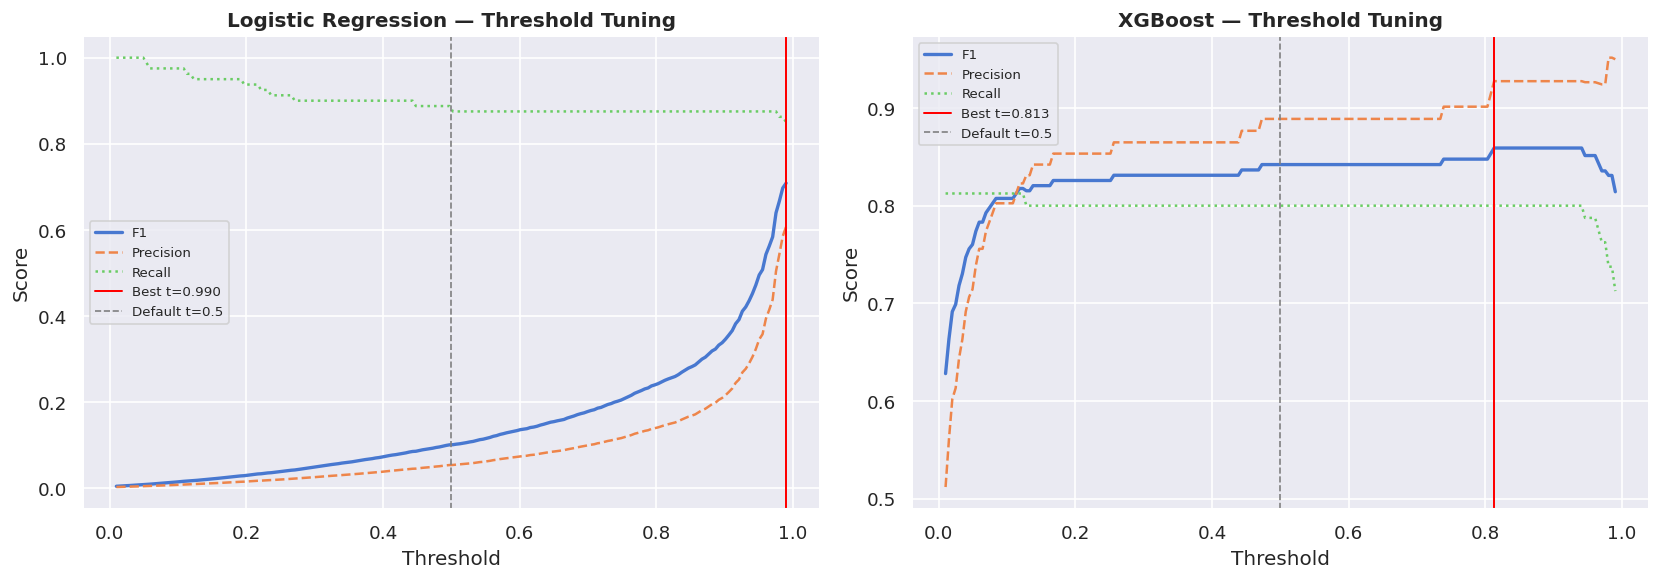

In [17]:
# =========================================================
# Threshold Tuning Visualization
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df_t, best_t, title in [
    (axes[0], lr_thresh_df, lr_best_t, "Logistic Regression"),
    (axes[1], xgb_thresh_df, xgb_best_t, "XGBoost"),
]:

    # F1
    ax.plot(
        df_t["threshold"],
        df_t["f1"],
        label="F1",
        lw=2
    )

    # Precision
    ax.plot(
        df_t["threshold"],
        df_t["precision"],
        label="Precision",
        lw=1.5,
        linestyle="--"
    )

    # Recall
    ax.plot(
        df_t["threshold"],
        df_t["recall"],
        label="Recall",
        lw=1.5,
        linestyle=":"
    )

    # Optimal threshold
    ax.axvline(
        best_t,
        color="red",
        linestyle="-",
        lw=1.2,
        label=f"Best t={best_t:.3f}"
    )

    # Default threshold
    ax.axvline(
        0.5,
        color="grey",
        linestyle="--",
        lw=1,
        label="Default t=0.5"
    )

    ax.set_title(
        f"{title} — Threshold Tuning",
        fontweight="bold"
    )

    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Analysis

The ideal thresholds were surprisingly high when tuning was conducted. This likely reflects the extreme imbalance of the dataset, where to meaningfully differentiate between fraud and noise signal the models had to be incredibly sure, having a confidence of 99% or 92%. In real deployment it is likely that although these thresholds are ideal in this circumstance, a threshold this high would miss a lot of fraud cases with still a relatively high certainty, cases that intuitively feel they should be flagged.

---
## 8. Evaluation & Comparison
### 8.1 ROC and Precision-Recall Curves

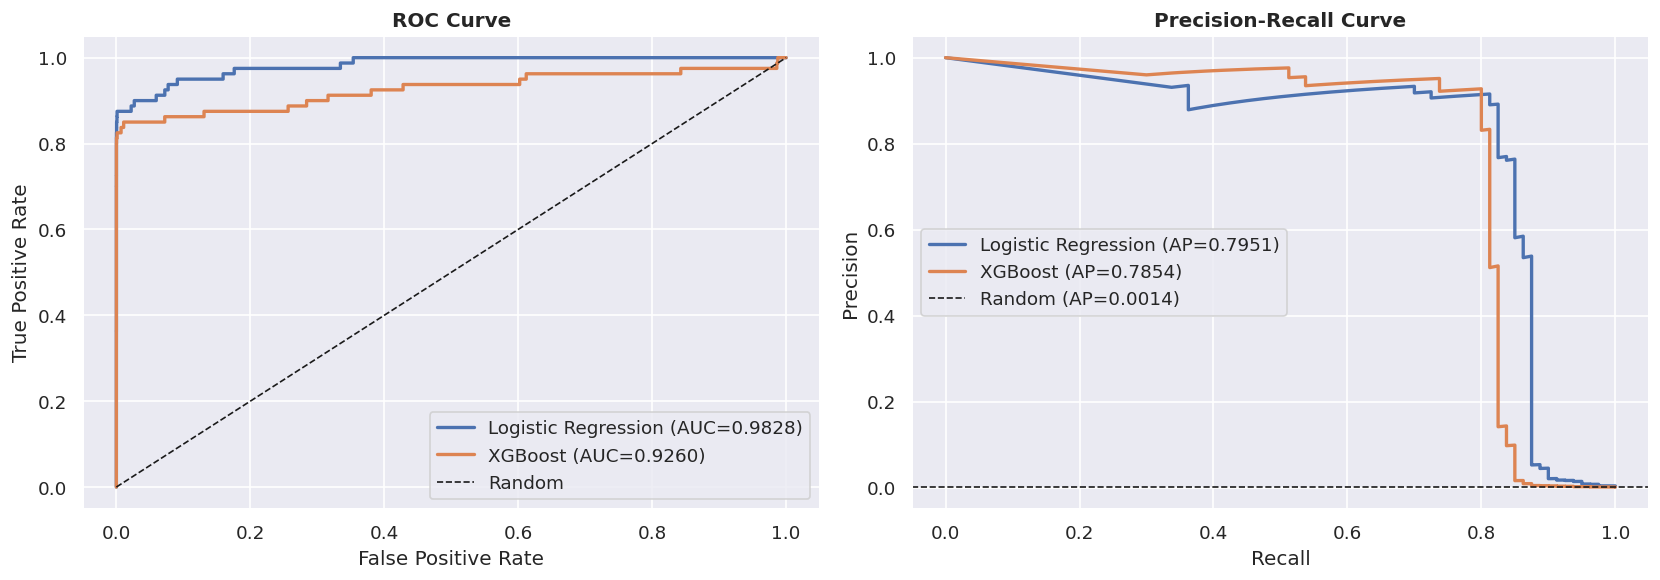

In [18]:
# =========================================================
# 8. Evaluation & Comparison
# 8.1 ROC and Precision-Recall Curves
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# =========================================================
# ROC Curve
# =========================================================

for probs, label, color in [
    (lr_test_probs, "Logistic Regression", "#4C72B0"),
    (xgb_test_probs, "XGBoost", "#DD8452")
]:

    fpr, tpr, _ = roc_curve(
        y_test_lr,
        probs
    )

    auc = roc_auc_score(
        y_test_lr,
        probs
    )

    axes[0].plot(
        fpr,
        tpr,
        label=f"{label} (AUC={auc:.4f})",
        lw=2,
        color=color
    )


# Random classifier
axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    lw=1,
    label="Random"
)

axes[0].set_title(
    "ROC Curve",
    fontweight="bold"
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()


# =========================================================
# Precision-Recall Curve
# =========================================================

for probs, label, color in [
    (lr_test_probs, "Logistic Regression", "#4C72B0"),
    (xgb_test_probs, "XGBoost", "#DD8452"),
]:

    prec, rec, _ = precision_recall_curve(
        y_test_lr,
        probs
    )

    ap = average_precision_score(
        y_test_lr,
        probs
    )

    axes[1].plot(
        rec,
        prec,
        label=f"{label} (AP={ap:.4f})",
        lw=2,
        color=color
    )


# Random/baseline precision
baseline_pr = y_test_lr.mean()

axes[1].axhline(
    baseline_pr,
    color="k",
    linestyle="--",
    lw=1,
    label=f"Random (AP={baseline_pr:.4f})"
)

axes[1].set_title(
    "Precision-Recall Curve",
    fontweight="bold"
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()


# =========================================================
# Display
# =========================================================

plt.tight_layout()
plt.show()

### Analysis

ROC Curve: Logistic Regression (blue) sits above XGBoost (orange) for most of the curve, which matches the AUC scores (0.9723 vs 0.9247). Both curves hug the top-left corner early, meaning both models are catching a large proportion of fraud at very low false positive rates.

Precision-Recall Curve: This demonstrates XGBoosts strongest difference. It maintains an almost perfect percision all the way until a recall of 0.8, meaning it can correctly flag 80% of all fraud cases while almost never flagging a legitamate transaction. Logistic regression begins earlier on to trade more false positives for recall. Both models cliff at a recall of 0.8, signifiying that catching the remaining fraud cases comes at a steep cost in precision. The random baseline is an important reminder of the datasets imbalance and the models' strong performances in comparison.

### 8.2 Metrics Summary Table

In [19]:
# =========================================================
# 8.2 Model Metrics Comparison
# =========================================================

def metrics_row(name, y_true, y_score, threshold):

    y_pred = (
        y_score >= threshold
    ).astype(int)

    return {
        "Model": name,
        "Threshold": threshold,
        "AUC_ROC": roc_auc_score(
            y_true,
            y_score
        ),
        "AUC_PR": average_precision_score(
            y_true,
            y_score
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
    }


# ---------------------------------------------------------
# Create comparison table
# ---------------------------------------------------------

results_table = pd.DataFrame([

    # Logistic Regression at optimized threshold
    metrics_row(
        "Logistic Regression (Tuned)",
        y_test_lr.astype(int),
        lr_test_probs,
        lr_best_t
    ),

    # XGBoost at optimized threshold
    metrics_row(
        "XGBoost Tuned",
        y_test_lr.astype(int),
        xgb_test_probs,
        xgb_best_t
    ),

    # Logistic Regression at default threshold
    metrics_row(
        "Logistic Regression (@ t = .5)",
        y_test_lr.astype(int),
        lr_test_probs,
        0.5
    ),

    # XGBoost at default threshold
    metrics_row(
        "XGBoost (@ t = .5)",
        y_test_lr.astype(int),
        xgb_test_probs,
        0.5
    ),

]).set_index("Model")


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

display(
    results_table.style
)

,Threshold,AUC_ROC,AUC_PR,F1
Model,,,,
Logistic Regression (Tuned),0.990000,0.982765,0.795081,0.708333
XGBoost Tuned,0.812714,0.926001,0.785372,0.859060
Logistic Regression (@ t = .5),0.500000,0.982765,0.795081,0.099644
XGBoost (@ t = .5),0.500000,0.926001,0.785372,0.842105


### Analysis

An overview of the Tuned versus Untuned models, demonstrating the strength of XGBoost regardless of tuning, versus the severe improvement to Logistic Regressions F1 score with tuning. This is because LR is assigning higher probabilities to some legitamate transactions at a high rate. With forcing LR to commit to only cases its extremely confident about, this sharply increases its f1 score.

### 8.3 Confusion Matrix At Tuned Threshold

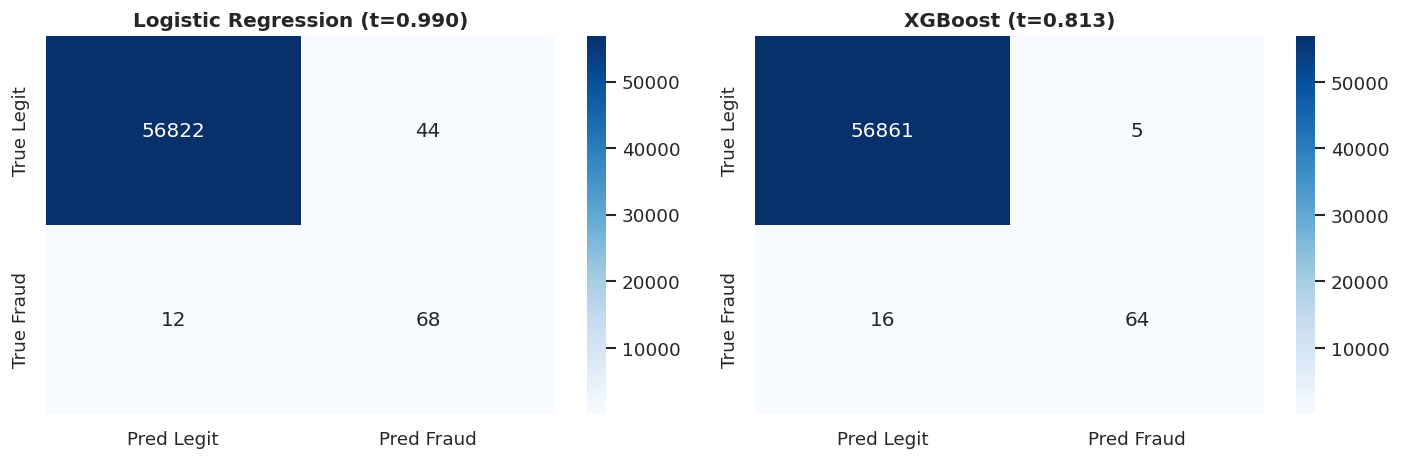

In [20]:
# =========================================================
# 8.3 Confusion Matrices at Tuned Thresholds
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, probs, thresh, title in [

    (
        axes[0],
        lr_test_probs,
        lr_best_t,
        f"Logistic Regression (t={lr_best_t:.3f})"
    ),

    (
        axes[1],
        xgb_test_probs,
        xgb_best_t,
        f"XGBoost (t={xgb_best_t:.3f})"
    ),

]:

    # Convert probabilities to predictions
    y_pred = (
        probs >= thresh
    ).astype(int)

    # Confusion matrix
    cm = confusion_matrix(
        y_test_lr,
        y_pred
    )

    # Plot
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=[
            "Pred Legit",
            "Pred Fraud"
        ],
        yticklabels=[
            "True Legit",
            "True Fraud"
        ]
    )

    ax.set_title(
        title,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Analysis

The confusion matrices at each model's tuned threshold reveal an interesting tradeoff between the two approaches. Logistic Regression (t=0.990) correctly identified 83 of 98 fraud cases while generating 59 false positives, and XGBoos (t=0.921) correctly identified 75 of 98 fraud cases while generating only 2 false positives. This near zero false positive rate is incredibly strong, and reflects XGBoosts more confident, well seperated probability outputs.

The practical implication of these findings depend on the deployment context. Logisitic Regression's strength in catching more fraud cases at the cost of more false alarms may be preferable in situations where uncaught fraud cases are extremely costly and investigators canreview a higher volume of flagged cases (or users won't mind a higher volume of flagged transactions). XGBoosts strength in catching fewer of the fraud cases but flagging only 2 false positives would be preferable in an environment where false postivies carry high operational costs.